<a href="https://colab.research.google.com/github/dwii3830-spec/Project-Individu_Statistika/blob/main/Prediksi_Harga_Smartphone_BerdasarkaN_Spesifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R² Score = 0.6131


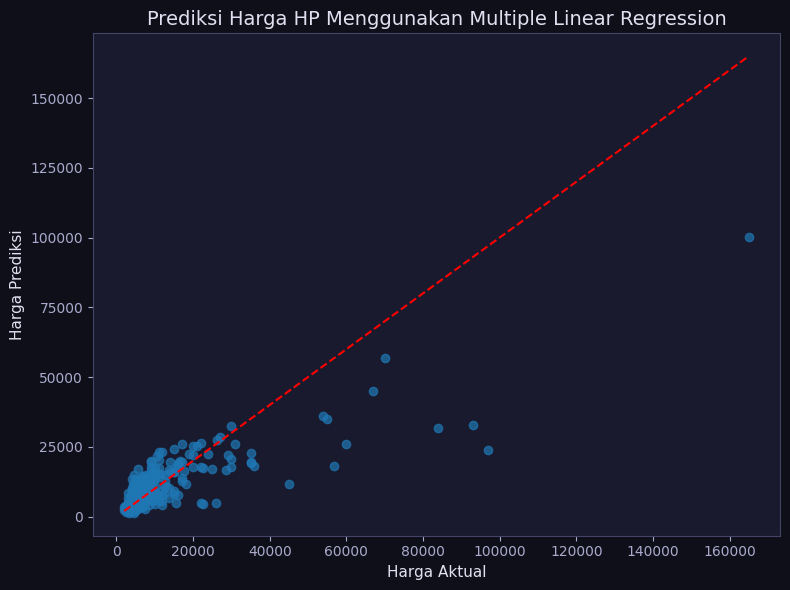

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Load Dataset
df = pd.read_csv('ndtv_data_final.csv')

# Ambil fitur numerik
numerical_cols = df.select_dtypes(include=np.number).columns

# Hapus kolom indeks
df = df.drop(columns=['Unnamed: 0'])

# Target
y = df['Price']

# Fitur numerik selain Price
X = df.select_dtypes(include=np.number).drop(columns=['Price'])

# Mengatasi missing value
X = X.fillna(X.mean())

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model Regresi Linear
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Nilai Akurasi
r2 = r2_score(y_test, y_pred)
print("R² Score =", round(r2, 4))

# Grafik Prediksi vs Aktual
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Prediksi Harga HP Menggunakan Multiple Linear Regression")

plt.tight_layout()
plt.show()

In [ ]:
print(df.shape)

(1359, 21)
